In [29]:
#로컬에서 mac gpu사용 코드
# import torch
# print(torch.__version__)
# print(torch.backends.mps.is_available())
# print(torch.backends.mps.is_built())
import os
print(os.getcwd())


/content


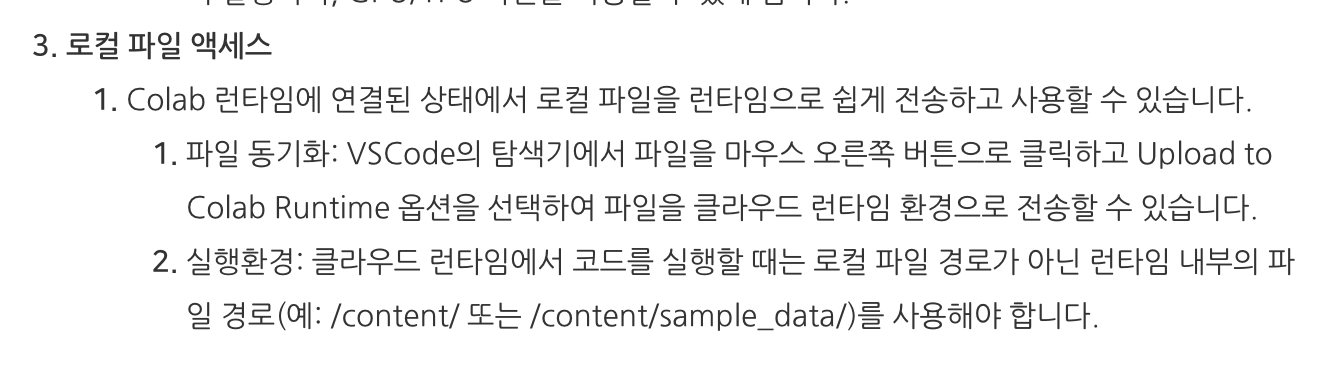
### 로컬에서 확장으로 colab 클라우드 활용하면 런타임을 올려서 돌리기떄문에 마운트나 따로 파일에 저장되있는걸 불러오지못함, 로컬에서 모델저장하거나 파일불러오거나 모듈 가져올거면 같은 런타임에 파일 업로드해서 참조하거나 같은 런타임에서 한번에 돌려야함 즉, 파일 2개는 동시에 못함 다른파일에서 저장한걸 현재파일에서 저장된값의 경로를 통해 가져오지는 못함

In [30]:
#마운트 확인 코드
import os
print(os.getcwd())
print(os.path.isdir("/content/drive"))
print(os.listdir("/content/drive")[:5])


/content
True
['MyDrive']


In [31]:
# from google.colab import drive
# drive.mount('/content/drive')
import sys
# sys.path.append('/content/drive/MyDrive/Colab Notebooks/LEVEL 1/torch')
sys.path.append('/content/drive/MyDrive/Colab Notebooks/torch')
from multiclass_functions1 import * # all , 사용자 모듈에서 모든함수 가져와라
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# print(DEVICE)
#DEVICE = "mps" if torch.backends.mps.is_available() else "cpu" #맥북 gpu로 돌림
print(DEVICE)

cuda


In [32]:
BATCH_SIZE = 32
LR = 1e-3
EPOCH = 5
criterion = nn.CrossEntropyLoss()
new_model_train = False #True일때만 새로 모델에 학습
model_type = "MLP" #다른 모델로 바꿔도 된다, 구현되어있으면
dataset = "MNIST"
#save_model_path = f"/content/drive/MyDrive/Colab Notebooks/results/{model_type}_{dataset}.pt"
save_model_path = f"/content/drive/MyDrive/Colab Notebooks/torch/results/{model_type}_{dataset}.pt"
#save_model_path = f"/Users/jeonminkyu/Desktop/torch/results/{model_type}_{dataset}.pt"

In [33]:
transform = transforms.ToTensor()
#train_DS = datasets.MNIST(root = '/content/drive/MyDrive/Colab Notebooks/data', train=True, download=True, transform=transform)
#test_DS = datasets.MNIST(root = '/content/drive/MyDrive/Colab Notebooks/data', train=False, download=True, transform=transform)
train_DS = datasets.MNIST(root = '/content/drive/MyDrive/Colab Notebooks/data', train=True, download=True, transform=transform)
test_DS = datasets.MNIST(root = '/content/drive/MyDrive/Colab Notebooks/data', train=False, download=True, transform=transform)
train_DL = torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
train_DL = torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

In [34]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fcs = nn.Sequential(nn.Linear(28*28, 30),
                                 nn.BatchNorm1d(30),
                                 nn.ReLU(),
                                 nn.Linear(30, 10))
    def forward(self,x):
        x = torch.flatten(x, start_dim=1)
        x = self.fcs(x)
        return x

In [35]:
#globals()[model_type]()를 통해 글로벌 변수를 불러와서 딕셔너리 인덱싱으로 MLP클래스를 불러온다.
model = globals()[model_type]().to(DEVICE) # globals() => global 변수들이 딕셔너리 형태로, 따라서 globals()[model_type]는 'MLP'라는 string으로 인덱싱 한 것, 위에 'MLP'를 'CNN'으로 바꿔도 밑에 코드 동작
print(model)

x_batch, _ = next(iter(train_DL))
print(x_batch.shape)

model.eval()
with torch.no_grad():
    print(model(x_batch.to(DEVICE)).shape)

MLP(
  (fcs): Sequential(
    (0): Linear(in_features=784, out_features=30, bias=True)
    (1): BatchNorm1d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=30, out_features=10, bias=True)
  )
)
torch.Size([32, 1, 28, 28])
torch.Size([32, 10])


In [36]:
if new_model_train:
    optimizer = optim.Adam(model.parameters(), lr = LR)
    loss_history = Train(model, train_DL, criterion, optimizer, EPOCH)

    torch.save(model, save_model_path)

    plt.plot(range(1,EPOCH+1),loss_history)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Train Loss")
    plt.grid()

In [ ]:
load_model = torch.load(save_model_path, map_location=DEVICE, weights_only=False)

In [ ]:
Test(load_model, test_DL)
print(count_params(load_model))

Test accuracy: 9687/10000 (96.9 %)
23920


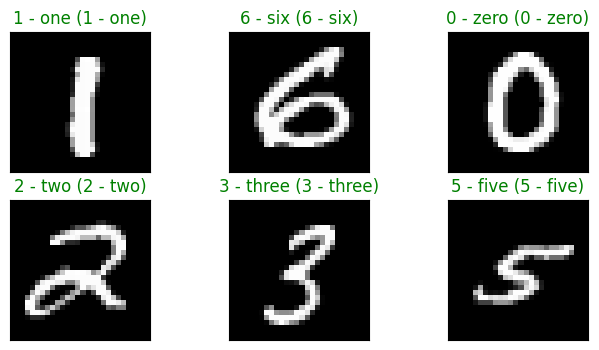

In [ ]:
Test_plot(load_model, test_DL)

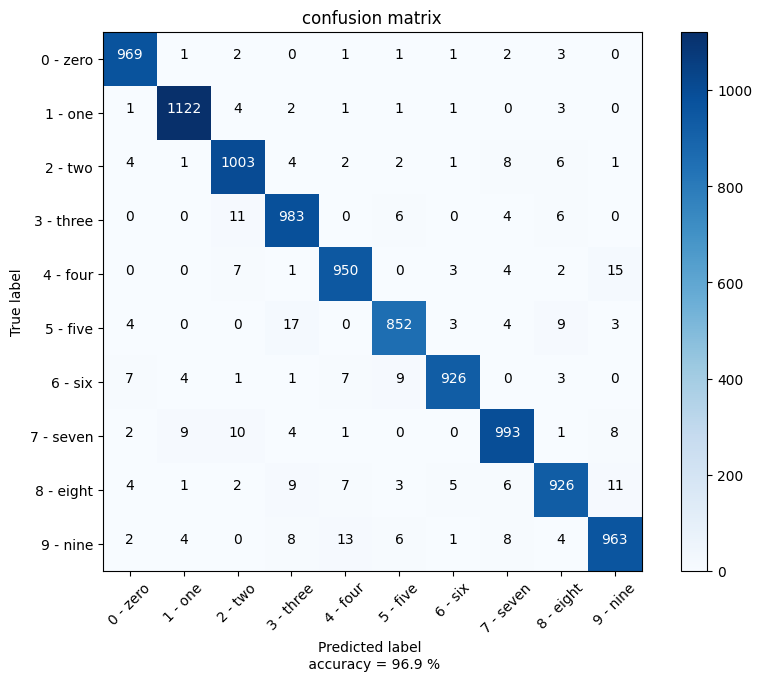

In [ ]:
confusion = get_conf(load_model, test_DL)
plot_confusion_matrix(confusion, test_DS.classes)
plt.xticks(rotation=45);

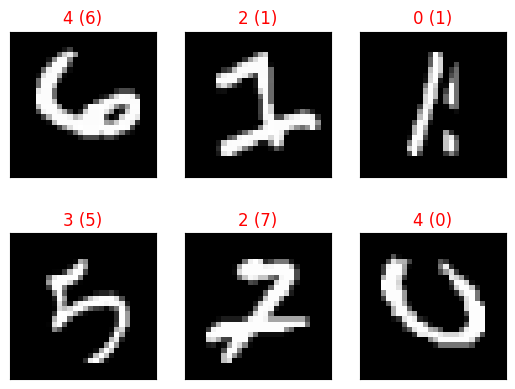

In [ ]:
# 틀린 것만 모아서 보자
cnt = 0
load_model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_DL:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        y_hat = load_model(x_batch)
        pred = y_hat.argmax(dim=1)

        false_idx = pred!=y_batch
        X_false=x_batch[false_idx,...].to("cpu")
        pred_false=pred[false_idx,...].to("cpu")
        Y_false=y_batch[false_idx,...].to("cpu")

        if X_false.shape[0] != 0:
            if cnt==6:
                break
            for i in range(X_false.shape[0]):
                cnt += 1
                pred_class = pred_false[i].item()
                true_class = Y_false[i].item()
                plt.subplot(2,3, cnt, xticks=[], yticks=[])
                plt.imshow(X_false[i,0,...], cmap="gray")
                plt.title(f"{pred_class} ({true_class})",color=("g" if pred_class==true_class else "r"))
                if cnt==6:
                    break